=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


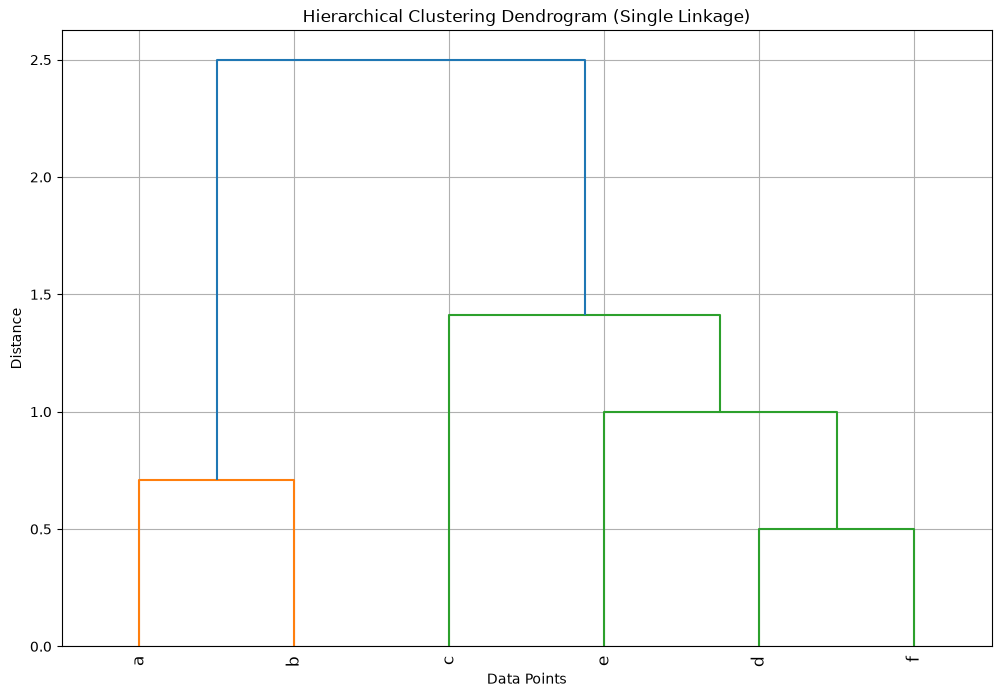

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

# 1. Dataset sederhana
data = np.array(
    [
        [1.0, 1.0],  # a
        [1.5, 1.5],  # b
        [5.0, 5.0],  # c
        [3.0, 4.0],  # d
        [4.0, 4.0],  # e
        [3.0, 3.5],  # f
    ]
)

# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric="euclidean")
distance_df = pd.DataFrame(
    squareform(distance_matrix),
    columns=["a", "b", "c", "d", "e", "f"],
    index=["a", "b", "c", "d", "e", "f"],
)

# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)

# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method="single")

# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=["a", "b", "c", "d", "e", "f"], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

ersiapan Data (numpy)Program membuat 6 titik koordinat 2D ($a$ sampai $f$). Titik-titik yang posisinya saling berdekatan secara visual akan cenderung bergabung lebih awal.Perhitungan Jarak (scipy.spatial & pandas)Fungsi pdist menghitung jarak lurus (Euclidean Distance) antar setiap pasangan titik menggunakan rumus:$$d = \sqrt{(x_2 - x_1)^2 + (y_2 - y_1)^2}$$Fungsi squareform dan pd.DataFrame mengubah hasil perhitungan tersebut menjadi matriks simetris $6 \times 6$ agar mudah dibaca dalam bentuk tabel jarak antartitik.Proses Pengelompokan (scipy.cluster.hierarchy.linkage)Fungsi linkage mengelompokkan data secara bertahap dari bawah ke atas (bottom-up). Karena menggunakan method='single' (Single Linkage), jarak antara dua kelompok (cluster) ditentukan oleh pasangan titik dengan jarak terdekat/terpendek di antara keduanya.Visualisasi Dendrogram (matplotlib & dendrogram)Hasil pengelompokan digambar dalam bentuk diagram pohon (dendrogram):Sumbu X: Menampilkan label data ($a, b, c, d, e, f$).Sumbu Y: Menunjukkan nilai jarak saat dua titik/cluster bergabung. Semakin rendah garis penghubung horizontalnya, semakin dekat dan mirip kedua titik tersebut.

In [5]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


import pandas as pd
Mengimpor library Pandas, yaitu library Python yang populer untuk analisis dan manipulasi data. Singkatan pd digunakan sebagai nama alias standar agar pemanggilan fungsi Pandas lebih singkat.

df = pd.read_csv("Mall_Customers.csv")

Fungsi read_csv() membaca file berkekstensi .csv yang bernama "Mall_Customers.csv".

Data tersebut dikonversi menjadi struktur data tabel 2 dimensi yang disebut DataFrame dan disimpan ke dalam variabel df.

df.head()
Menampilkan 5 baris pertama dari DataFrame df ke layar. Fungsi ini berguna untuk melihat pratinjau (preview) data secara cepat (seperti nama-nama kolom, tipe data awal, dan contoh nilai) untuk memastikan file berhasil dimuat dengan benar.

In [6]:
x = df.iloc[:, [3, 4]].values

df.iloc[...]

iloc singkatan dari Integer Location, yaitu metode di Pandas untuk memilih data berdasarkan urutan indeks posisi angka (bukan berdasarkan nama kolom/baris).

[:, [3, 4]]

Tanda titik dua pertama : berarti memilih semua baris yang ada di dalam DataFrame.

Elemen [3, 4] berarti mengambil kolom indeks ke-3 dan indeks ke-4.

Catatan pada dataset Mall Customers: Kolom indeks ke-3 biasanya adalah Annual Income (k$) dan indeks ke-4 adalah Spending Score (1-100).

.values
Mengubah hasil seleksi tabel Pandas (DataFrame) menjadi bentuk array NumPy 2 dimensi agar dapat langsung diolah oleh algoritma Machine Learning (seperti K-Means atau Hierarchical Clustering dari SciPy/Scikit-Learn).

x = ...
Menyimpan array hasil seleksi tersebut ke dalam variabel x sebagai fitur utama yang akan dikelompokkan.

In [7]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

from sklearn.preprocessing import StandardScaler
Mengimpor kelas StandardScaler dari modul pemrosesan awal (preprocessing) library scikit-learn.

data_scaler = StandardScaler()
Membuat objek/inisialisasi pemroses data bernama data_scaler.

scaled_data = data_scaler.fit_transform(x)
Proses transformasi ini mengubah skala nilai pada array x sedemikian rupa sehingga setiap fitur/kolom memiliki:

Rata-rata (mean) = 0

Standar deviasi (standard deviation) = 1

Rumus yang digunakan adalah:scaled_data.shape
Menampilkan ukuran/dimensi dari array scaled_data dalam bentuk tuple (jumlah_baris, jumlah_kolom). Untuk dataset Mall Customers, hasilnya biasanya adalah (200, 2) yang menandakan ada 200 data pelanggan dan 2 fitur/kolom.

In [8]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

from scipy.cluster.hierarchy import linkage, dendrogram

linkage: Fungsi utama untuk menghitung pengelompokan hierarki bertahap (bottom-up).

dendrogram: Fungsi untuk memvisualisasikan hirarki cluster ke dalam bentuk diagram pohon.

clustering = linkage(scaled_data, method="complete", metric="euclidean")
Fungsi linkage menerima tiga parameter utama:

scaled_data: Data input yang nilainya sudah dinormalisasi/distandarisasi agar skala antar fitur seimbang.

method="complete": Menggunakan strategi Complete Linkage (metode tetangga terjauh).

Cara kerjanya: Jarak antara dua cluster ditentukan oleh pasangan titik dengan jarak paling jauh/maksimum di antara anggota kedua cluster tersebut. Metode ini cenderung menghasilkan cluster yang lebih padat (compact) dan berukuran seimbang dibandingkan metode Single Linkage.

metric="euclidean": Menggunakan rumus jarak Euclidean (jarak garis lurus) untuk menghitung perbedaan antar titik data.

clustering
Variabel ini menyimpan matriks hubungan/penggabungan (linkage matrix) yang berisi catatan step-by-step titik/cluster mana saja yang digabungkan pada setiap iterasi beserta nilai jaraknya. Matriks inilah yang nantinya dimasukkan ke fungsi dendrogram() untuk digambar.

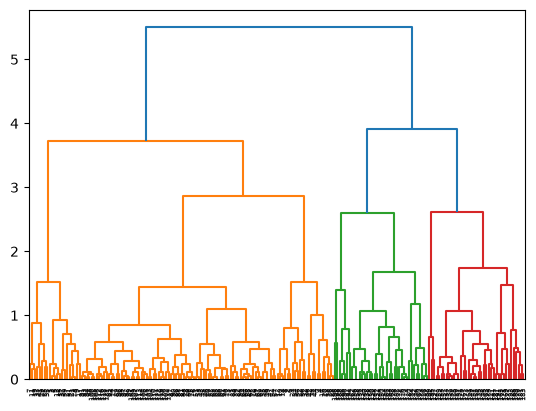

In [9]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

import matplotlib.pyplot as plt
Mengimpor modul pyplot dari library Matplotlib yang bertugas untuk membuat dan menampilkan area grafik/plot.

dendrogram(clustering)

Memproses matriks penggabungan (linkage matrix) dari variabel clustering.

Menghasilkan garis-garis berbentuk U terbalik (pohon hirarki) yang menunjukkan titik mana saja yang bergabung dan pada tingkat jarak berapa penggabungan itu terjadi.

Sumbu X: Mewakili indeks dari setiap sampel data (pelanggan).

Sumbu Y: Mewakili nilai jarak (Euclidean) tempat penggabungan cluster terjadi. Semakin tinggi garis penghubungnya, semakin jauh perbedaan antar kelompok.

plt.show()
Menampilkan hasil visualisasi dendrogram secara penuh ke layar layar notebook/praktek Anda.

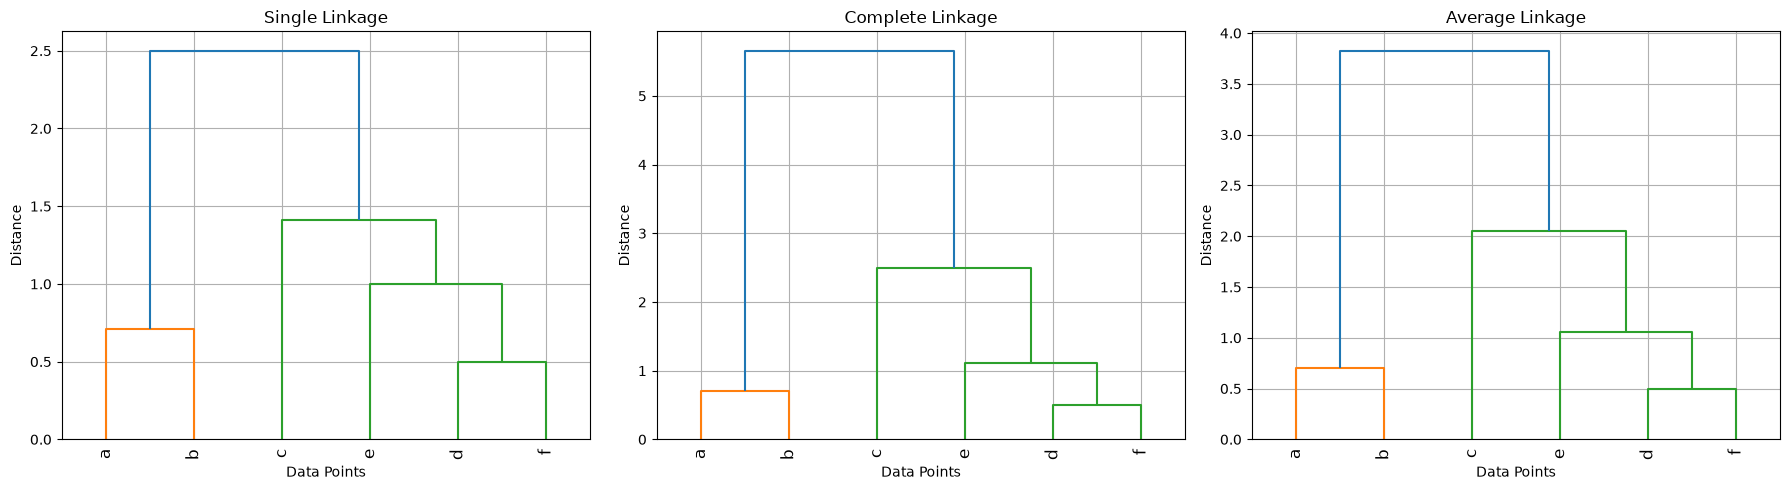

In [10]:
#Tugas 
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Dataset sederhana (sesuai percobaan pertama)
data = np.array(
    [
        [1.0, 1.0],  # a
        [1.5, 1.5],  # b
        [5.0, 5.0],  # c
        [3.0, 4.0],  # d
        [4.0, 4.0],  # e
        [3.0, 3.5],  # f
    ]
)

labels = ["a", "b", "c", "d", "e", "f"]

# 2. Hitung linkage untuk ketiga metode
linkage_single = linkage(data, method="single")
linkage_complete = linkage(data, method="complete")
linkage_average = linkage(data, method="average")

# 3. Plot perbandingan dendrogram dalam 1 figure
plt.figure(figsize=(18, 5))

# Plot Single Linkage
plt.subplot(1, 3, 1)
dendrogram(linkage_single, labels=labels, leaf_rotation=90)
plt.title("Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

# Plot Complete Linkage
plt.subplot(1, 3, 2)
dendrogram(linkage_complete, labels=labels, leaf_rotation=90)
plt.title("Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

# Plot Average Linkage
plt.subplot(1, 3, 3)
dendrogram(linkage_average, labels=labels, leaf_rotation=90)
plt.title("Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)

plt.tight_layout()
plt.show()

Single Linkage (Tetangga Terdekat):

Mengukur jarak berdasarkan pasangan titik terdekat antar kelompok.

Cenderung membentuk struktur memanjang/rantai (chaining effect).

Complete Linkage (Tetangga Terjauh):

Mengukur jarak berdasarkan pasangan titik terjauh antar kelompok.

Mengahsilkan kelompok yang lebih padat (compact) dan berukuran seimbang.

Average Linkage (Rata-rata Jarak):

Mengukur rata-rata jarak dari seluruh pasangan titik antar kelompok.

Merupakan kompromi netral antara Single Linkage dan Complete Linkage.